Import Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Normalization

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Organize cloumns into bianary, categorical and numerical data
bianary_cols = [ 'Partner', 'Dependents', 'PhoneService',
                 'PaperlessBilling', 'Churn']
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaymentMethod']
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# seniors are already binomial, and gender needs to be done seperatly


In [8]:
# Normalize Numarical columns
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Round to 2 decimal places
df[numerical_cols] = df[numerical_cols].round(2)


In [9]:

# Convert Yes/No to 1/0
for col in bianary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [10]:
# change gender from feamale, male to 0/1
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

Do customers subscribed to certain services have higher churn rates than others?

In [12]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

service_churn = {}

for col in service_cols:
    service_churn[col] = df[df[col] == 'Yes']['Churn'].mean() * 100

service_churn = pd.DataFrame.from_dict(
    service_churn,
    orient='index',
    columns=['ChurnRate']
).sort_values('ChurnRate', ascending=False)

service_churn

,ChurnRate
StreamingTV,30.070188
StreamingMovies,29.941435
DeviceProtection,22.502064
OnlineBackup,21.531494
TechSupport,15.166341
OnlineSecurity,14.611194


<Figure size 800x500 with 0 Axes>

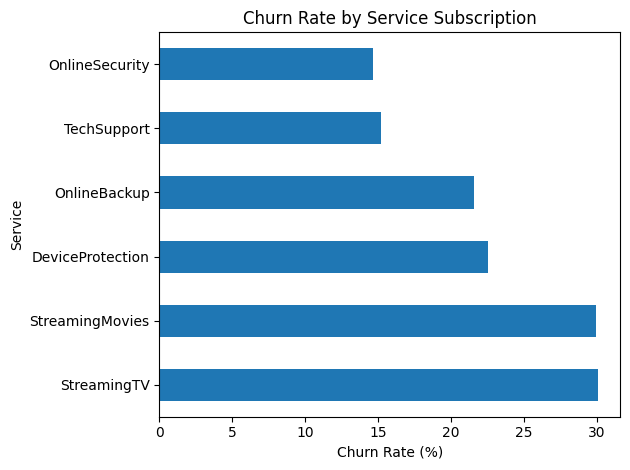

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

service_churn.plot(
    kind='barh',
    legend=False
)

plt.title('Churn Rate by Service Subscription')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Service')
plt.tight_layout()

plt.show()

Do customers with multiple services churn less than customers with only one?


In [13]:
# add a new column that shows 0 if they only have one service 1 if they have multiple
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Count active services
df['NumServices'] = (df[service_cols] == 'Yes').sum(axis=1)

# 0 = one or fewer services, 1 = multiple services
df['MultipleServices'] = (df['NumServices'] > 1).astype(int)

In [14]:
# Churn rate by multiple services status
churn_summary = (
    df.groupby('MultipleServices')['Churn']
      .agg(['count', 'sum', 'mean'])
      .reset_index()
)

churn_summary['ChurnRate'] = churn_summary['mean'] * 100
churn_summary

,MultipleServices,count,sum,mean,ChurnRate
0,0,3185,917,0.287912,28.791209
1,1,3858,952,0.246760,24.675998


Which customer characteristics are most strongly associated with churn?

In [15]:
character_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

results = []

for col in character_cols:
    churn_rates = df.groupby(col)['Churn'].mean() * 100

    for category, rate in churn_rates.items():
        results.append({
            'Characteristic': col,
            'Category': category,
            'ChurnRate': round(rate, 2)
        })

characteristics_churn = pd.DataFrame(results)
characteristics_churn

,Characteristic,Category,ChurnRate
0,gender,0,26.92
1,gender,1,26.16
2,SeniorCitizen,0,23.61
3,SeniorCitizen,1,41.68
4,Partner,0,32.96
5,Partner,1,19.66
6,Dependents,0,31.28
7,Dependents,1,15.45


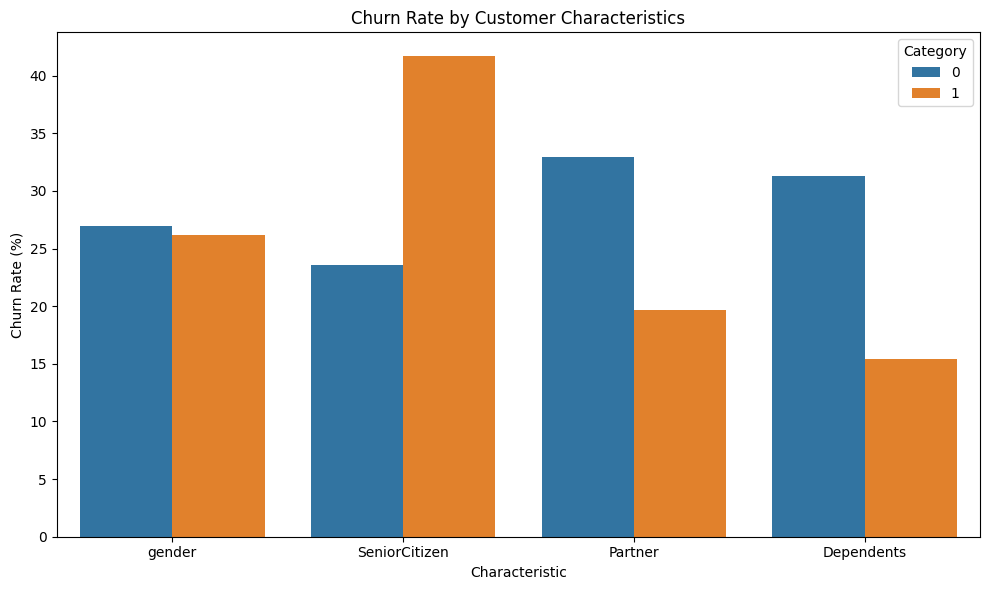

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=characteristics_churn,
    x='Characteristic',
    y='ChurnRate',
    hue='Category'
)

plt.title('Churn Rate by Customer Characteristics')
plt.xlabel('Characteristic')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Category')
plt.tight_layout()

plt.show()